<a href="https://colab.research.google.com/github/FebriansyahMonanda83/Data_Science/blob/main/Disabilitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Koneksi Drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/DPT_1606/142.xlsx'
df = pd.read_excel(path)

# Standardisasi kolom
df.columns = [c.strip().replace(' ', '_').upper() for c in df.columns]

Mounted at /content/drive


In [3]:
# 1. Fitur Usia & Generasi
tahun_analisis = 2026
df['TAHUN_LAHIR'] = pd.to_datetime(df['TANGGAL_LAHIR'], errors='coerce').dt.year
df['USIA'] = tahun_analisis - df['TAHUN_LAHIR']

def get_gen(u):
    if u <= 27: return 'Gen Z'
    elif u <= 43: return 'Milenial'
    elif u <= 59: return 'Gen X'
    else: return 'Baby Boomer/Silent'

df['KELOMPOK_GEN'] = df['USIA'].apply(get_gen)

# 2. Fitur Disabilitas
# Mengubah kode disabilitas menjadi deskripsi teks agar lebih informatif
mapping_dis = {'0': 'Non', '1': 'Fisik', '2': 'Intelektual', '3': 'Mental',
               '4': 'Wicara', '5': 'Rungu', '6': 'Netra'}
df['JENIS_DISABILITAS'] = df['DISABILITAS'].fillna('0').astype(str).map(mapping_dis)
df['IS_DISABILITAS'] = df['DISABILITAS'].fillna('0').apply(lambda x: 1 if x != '0' else 0)

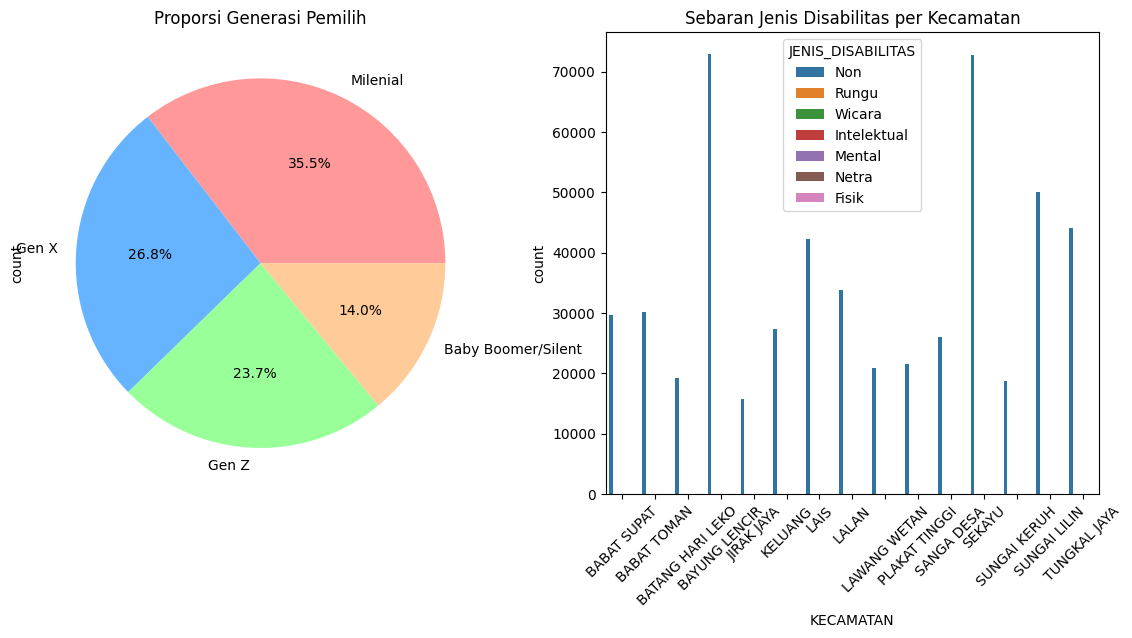

In [4]:
plt.figure(figsize=(14, 6))

# Plot A: Komposisi Generasi
plt.subplot(1, 2, 1)
df['KELOMPOK_GEN'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Proporsi Generasi Pemilih')

# Plot B: Sebaran Disabilitas per Kecamatan
plt.subplot(1, 2, 2)
sns.countplot(data=df[df['IS_DISABILITAS']==1], x='KECAMATAN', hue='JENIS_DISABILITAS')
plt.xticks(rotation=45)
plt.title('Sebaran Jenis Disabilitas per Kecamatan')
plt.show()

In [5]:
# Agregasi per TPS
tps_agg = df.groupby('TPS').agg({
    'IS_DISABILITAS': 'sum',
    'USIA': 'count'
}).rename(columns={'USIA': 'TOTAL_PEMILIH'})

# Simulasi variabel target: Menit tambahan (asumsi 1 disabilitas butuh +5 menit)
tps_agg['MENIT_TAMBAHAN'] = (tps_agg['IS_DISABILITAS'] * 5.0) + np.random.normal(0, 2, len(tps_agg))

# Regresi Linear
X = tps_agg[['IS_DISABILITAS']]
y = tps_agg['MENIT_TAMBAHAN']
model = LinearRegression().fit(X, y)

print(f"Koefisien Regresi: {model.coef_[0]:.2f}")
# Output ini memberitahukan: Setiap 1 orang disabilitas menambah waktu layanan sekian menit.

Koefisien Regresi: 5.00
